In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [2]:
df=pd.read_csv(r"../data/processed/daily_sales.csv")

In [3]:
df.head()

,Unnamed: 0,ds,y
0,0,2010-12-01,58635.56
1,1,2010-12-02,46207.28
2,2,2010-12-03,45620.46
3,3,2010-12-05,31383.95
4,4,2010-12-06,53860.18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  305 non-null    int64  
 1   ds          305 non-null    object 
 2   y           305 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 7.3+ KB


In [5]:
df['ds'] = pd.to_datetime(df['ds'])

In [6]:
df.isnull().sum()

Unnamed: 0    0
ds            0
y             0
dtype: int64

In [7]:
train = df[:-30]
test = df[-30:]

In [8]:
model=Prophet()
model.fit(train)

17:55:39 - cmdstanpy - INFO - Chain [1] start processing
17:55:39 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
future = model.make_future_dataframe(periods=30)

In [10]:
forecast=model.predict(future)

In [11]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
300,2011-11-30,44043.014993,29416.108140,59275.863155
301,2011-12-01,52616.450392,36689.023080,67559.003342
302,2011-12-02,43771.562897,27645.601373,58846.248625
303,2011-12-03,60716.382772,46362.224604,75159.059505
304,2011-12-04,29832.298810,14272.381730,44031.819135


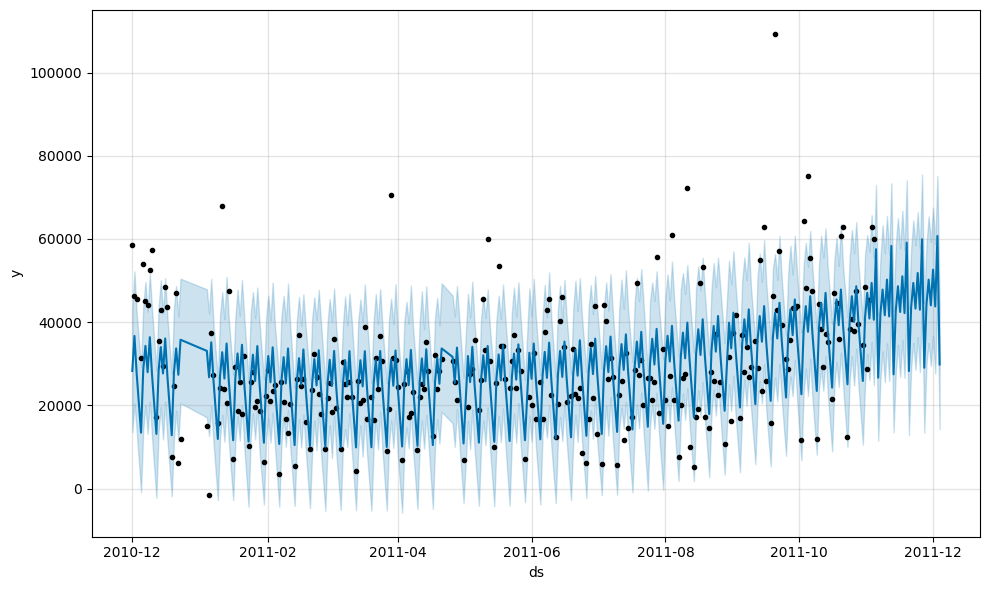

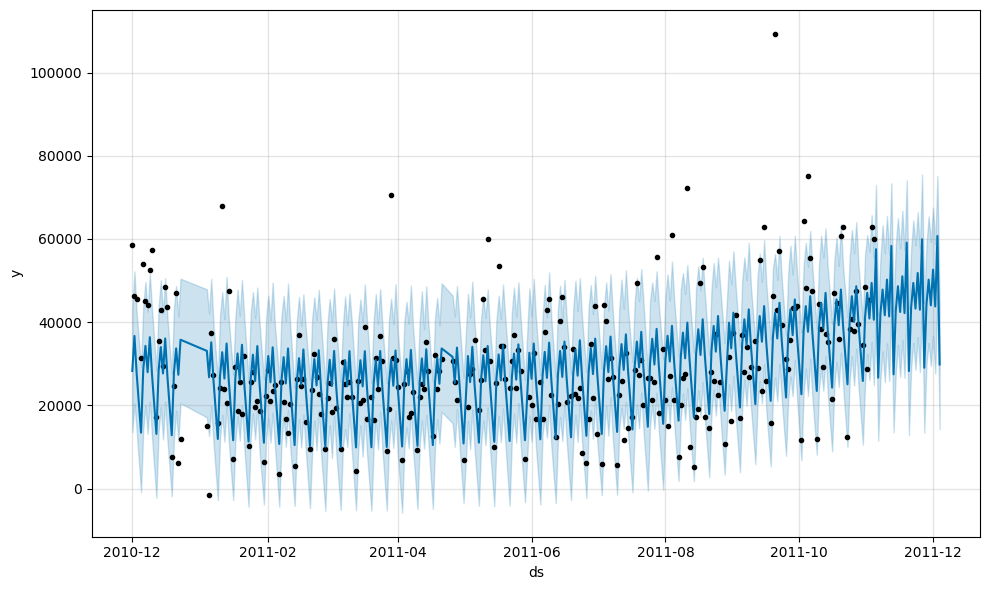

In [12]:
model.plot(forecast)

In [13]:
predictions = forecast[['ds', 'yhat']].tail(30)

merged = test.merge(predictions, on='ds')

In [14]:
mae = mean_absolute_error(merged['y'], merged['yhat'])

rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))

mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 15126.946732362627
RMSE: 20362.38833653103
MAPE: 24.870445949165344


In [15]:
forecast.to_csv("../data/forecasting/prophet_forecast.csv", index=False)

In [16]:
import joblib

joblib.dump(model, "../models/prophet_model.pkl")

['../models/prophet_model.pkl']

In [17]:
import mlflow

mlflow.set_experiment("RetailPulse")

with mlflow.start_run(run_name="Prophet_Model"):

    mlflow.log_param("model_type", "Prophet")

    mlflow.log_param("forecast_horizon", 30)

    mlflow.log_metric("MAE", mae)

    mlflow.log_metric("RMSE", rmse)

    mlflow.log_metric("MAPE", mape)

print("Prophet model logged successfully")

Prophet model logged successfully
